In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import os.path
import tensorflow as tf
import PIL
import PIL.Image
from random import randint
import datetime
from tensorflow.keras.models import load_model
import pickle
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import optuna
import gc

C:\Users\chail\anaconda3\envs\tf\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
SEED = 12

### Load CCSN dataset

In [3]:
PATH = "CCSN_v2"
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

dataset = tf.keras.preprocessing.image_dataset_from_directory(PATH,
                                      shuffle=True,
                                      label_mode='categorical',
                                      batch_size=BATCH_SIZE,
                                      image_size=IMG_SIZE)
class_names = dataset.class_names
num_classes = len(class_names)

Found 2543 files belonging to 11 classes.


In [4]:
class_names

['Ac', 'As', 'Cb', 'Cc', 'Ci', 'Cs', 'Ct', 'Cu', 'Ns', 'Sc', 'St']

### Split dataset into train, validation, and test sets with a 7:2:1 ratio

In [5]:
def get_dataset_partitions_tf(ds, ds_size, train_split=0.7, val_split=0.2, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)


    return train_ds, val_ds, test_ds

train_dataset, validation_dataset, test_dataset = get_dataset_partitions_tf(dataset, ds_size=len(dataset))

print('Size of training dataset batch: %d' % len(train_dataset))
print('Size of validation dataset batch: %d' % len(validation_dataset))
print('Size of test dataset batch: %d' % len(test_dataset))

Size of training dataset batch: 56
Size of validation dataset batch: 16
Size of test dataset batch: 8


In [2]:
IMG_SIZE = (224, 224)
NUM_CLASSES = 11
IMG_SHAPE = IMG_SIZE + (3,)

# Best params from Optuna
learning_rate = 0.00046023569715393677
dropout_rate = 0.4054434283399101
dense_units = 128
freeze_ratio = 0.7058989512901133
label_smoothing = 0.0770096984455205

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights="imagenet",
    include_preprocessing=True
)

base_model.trainable = True
base_layer_count = len(base_model.layers)
fine_tune_at = int(base_layer_count * freeze_ratio)

print("Number of layers in the base model:", base_layer_count)
print("Freeze until layer index:", fine_tune_at)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
x = tf.keras.layers.Dropout(dropout_rate)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)


Number of layers in the base model: 229
Freeze until layer index: 161


In [3]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 MobilenetV3small (Functiona  (None, 7, 7, 576)        939120    
 l)                                                              
                                                                 
 global_average_pooling2d (G  (None, 576)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               73856     
                                                             

In [7]:
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
    metrics=["accuracy"]
)

checkpoint_path = "best_mobilenetv3small.keras"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)
start_time = datetime.datetime.now()

history = model.fit(
    train_dataset,
    epochs=300,
    validation_data=validation_dataset,
    verbose=2,
    callbacks=[checkpoint_callback]
)

end_time = datetime.datetime.now()
period = end_time - start_time
print(f"Training time: {period.total_seconds():.2f} seconds")

Number of layers in the base model: 229
Freeze until layer index: 161
Epoch 1/300

Epoch 1: val_accuracy improved from -inf to 0.39453, saving model to best_mobilenetv3small.keras
56/56 - 15s - loss: 2.2186 - accuracy: 0.2456 - val_loss: 1.9084 - val_accuracy: 0.3945 - 15s/epoch - 269ms/step
Epoch 2/300

Epoch 2: val_accuracy improved from 0.39453 to 0.47266, saving model to best_mobilenetv3small.keras
56/56 - 9s - loss: 1.8953 - accuracy: 0.3728 - val_loss: 1.6983 - val_accuracy: 0.4727 - 9s/epoch - 160ms/step
Epoch 3/300

Epoch 3: val_accuracy improved from 0.47266 to 0.54747, saving model to best_mobilenetv3small.keras
56/56 - 9s - loss: 1.7406 - accuracy: 0.4473 - val_loss: 1.5213 - val_accuracy: 0.5475 - 9s/epoch - 157ms/step
Epoch 4/300

Epoch 4: val_accuracy improved from 0.54747 to 0.57172, saving model to best_mobilenetv3small.keras
56/56 - 9s - loss: 1.6709 - accuracy: 0.4620 - val_loss: 1.4500 - val_accuracy: 0.5717 - 9s/epoch - 155ms/step
Epoch 5/300

Epoch 5: val_accuracy 

In [8]:
with open('training_history.pkl', 'wb') as file:
    pickle.dump(history.history, file)

In [11]:
with open('training_history.pkl','rb') as file:
    history = pickle.load(file)

In [2]:
best_model = load_model("best_mobilenetv3small.keras")

In [11]:
best_model.metrics_names

['loss', 'accuracy']

In [12]:
val_loss = history['val_loss']
val_acc = history['val_accuracy']
train_loss = history['loss']
train_acc = history['accuracy']

### Training and validation accuracy and loss curves

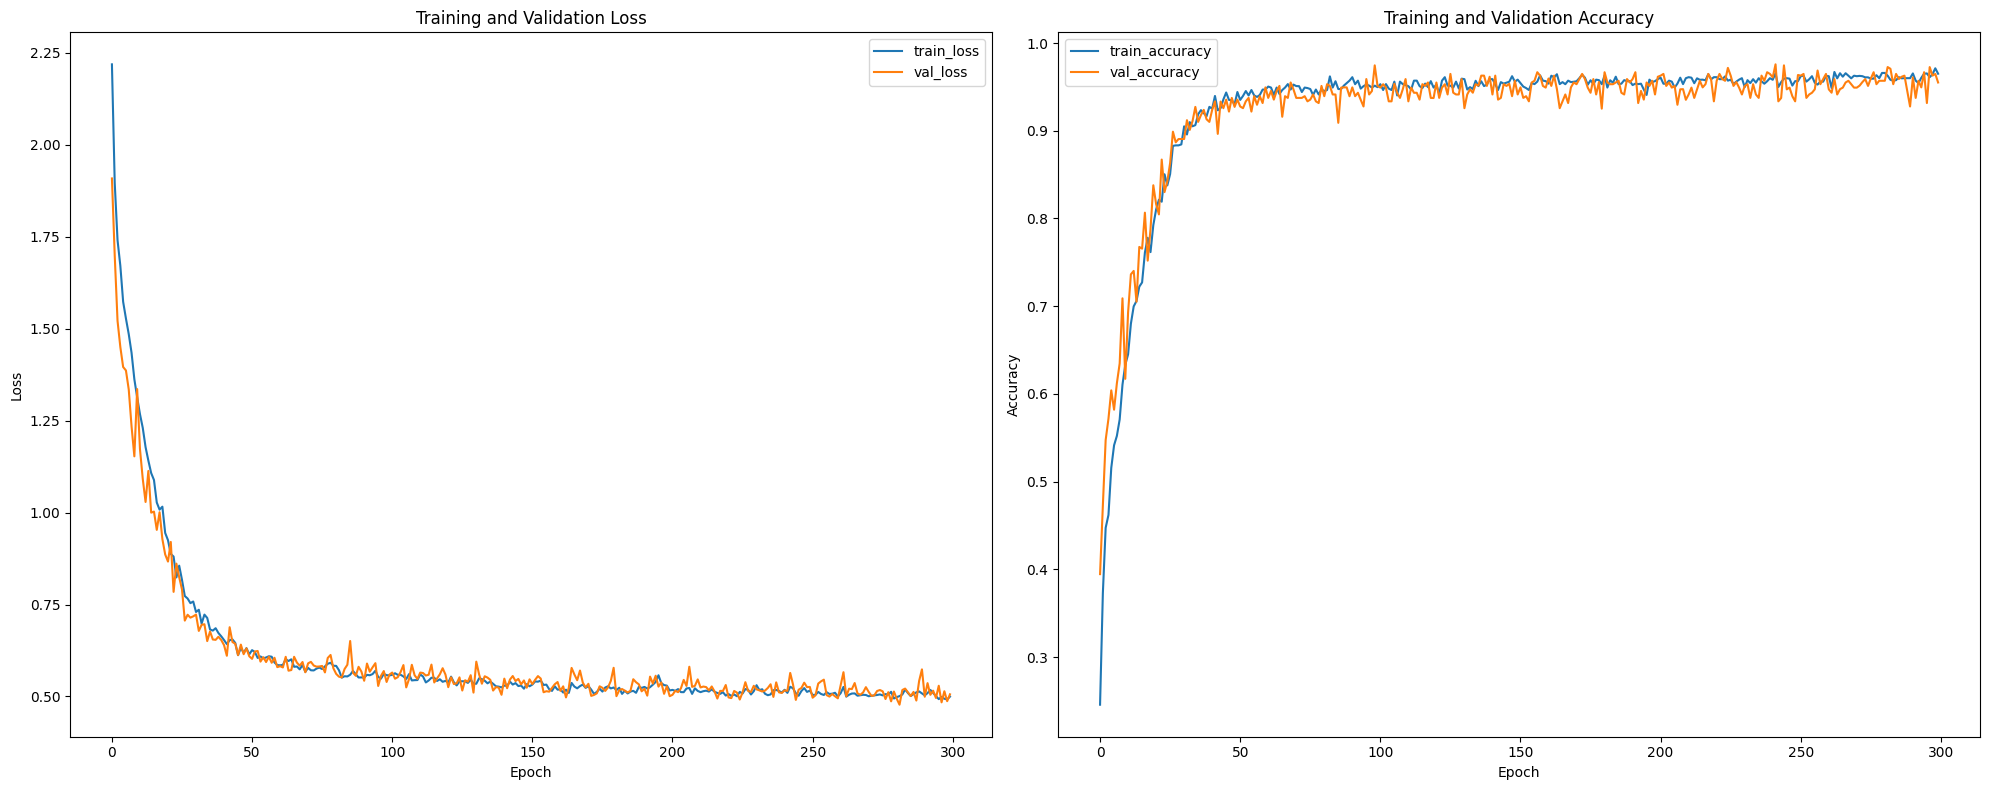

In [13]:
plt.figure(figsize=(20, 8))

# ---- Loss ----
plt.subplot(1, 2, 1)
plt.plot(train_loss)
plt.plot(val_loss)
plt.legend(['train_loss', 'val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')


plt.subplot(1, 2, 2)
plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(['train_accuracy', 'val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.savefig("training_performance.png", dpi=500)
plt.show()

In [9]:
images_list = []
labels_list = []

for images, labels in test_dataset:
    images_list.append(images)
    labels_list.append(labels)

x_test = np.concatenate(images_list)
y_test = np.concatenate(labels_list)

y_test = np.argmax(y_test, axis=-1)

prediction = best_model.predict(x_test)
y_pred = np.argmax(prediction, axis=-1)
print(classification_report(y_test, y_pred, target_names=class_names))
print(classification_report(y_test, y_pred, target_names=class_names,digits=4))

8/8 [==============================] - 0s 13ms/step
              precision    recall  f1-score   support

          Ac       1.00      0.88      0.93        16
          As       0.90      1.00      0.95        19
          Cb       1.00      1.00      1.00        16
          Cc       0.94      1.00      0.97        34
          Ci       0.91      1.00      0.95        10
          Cs       1.00      0.93      0.96        44
          Ct       1.00      0.92      0.96        13
          Cu       1.00      1.00      1.00        20
          Ns       0.97      1.00      0.98        30
          Sc       1.00      1.00      1.00        38
          St       0.94      0.94      0.94        16

    accuracy                           0.97       256
   macro avg       0.97      0.97      0.97       256
weighted avg       0.97      0.97      0.97       256

              precision    recall  f1-score   support

          Ac     1.0000    0.8750    0.9333        16
          As     0.9048   

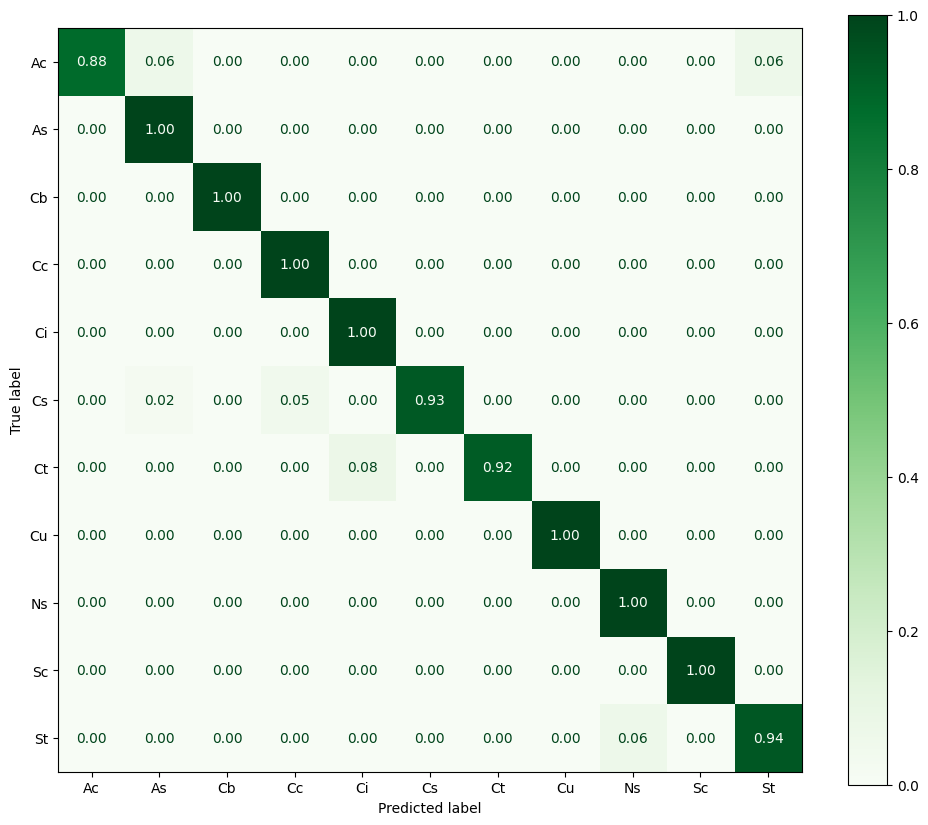

In [10]:
cm = confusion_matrix(y_test,y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10)) 
disp.plot(ax=ax,values_format='.2f',cmap ='Greens')
plt.savefig("confusion_matrix.png", dpi=500)
plt.show()

In [16]:
def plot_image(i, predictions_array, true_label, img):
  img = img[i]
  true_label = true_label[i]
  true_label = np.argmax(true_label)
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img.astype("uint8"))

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  true_label = np.argmax(true_label)
  plt.grid(False)
  plt.xticks(range(num_classes), class_names)
  plt.yticks([])
  thisplot = plt.bar(range(num_classes), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

def generate_random_indices(max_number, size):
  result = []
  random_number = randint(0, max_number - 1)
  while len(result) < size:
    while random_number in result:
      random_number = randint(0, max_number - 1)

    result.append(random_number)

  return result

In [17]:
images_test = []
labels_test = []

for batch in test_dataset:
  image_batch, label_batch = batch
  for i in image_batch:
    images_test.append(i)

  for i in label_batch:
    labels_test.append(i)

images_test = np.array(images_test)
labels_test = np.array(labels_test)
predictions = best_model.predict_on_batch(images_test)

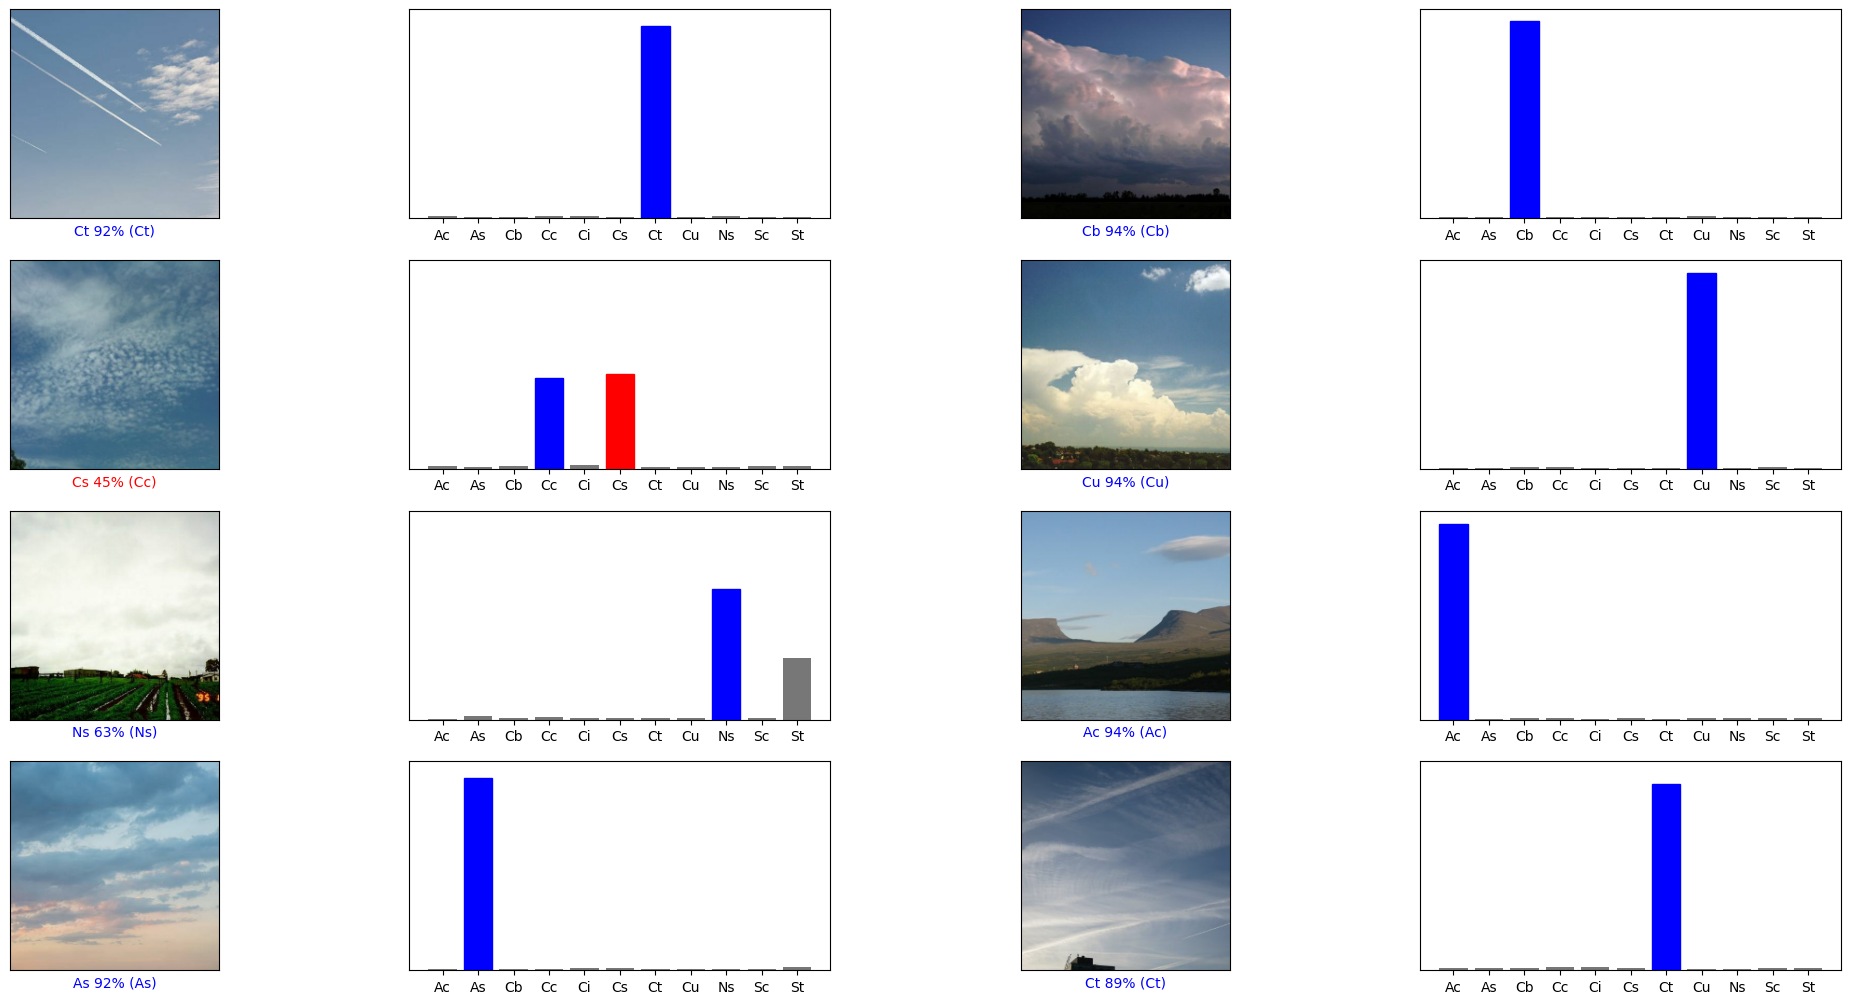

In [18]:
row_count = 4
col_count = 2
img_view_size = row_count * col_count
image_batch = images_test
label_batch = labels_test
indices = generate_random_indices(len(image_batch), img_view_size)

plt.figure(figsize=(12.5 * col_count, 3.12 * row_count))
for j in range(0, img_view_size):
  i = indices[j]

  #display image
  plt.subplot(row_count, 2 * col_count, 2 * j + 1)
  plot_image(i, predictions[i], label_batch, image_batch)

  #display prediction bar graph
  plt.subplot(row_count, 2 * col_count, (2 * j) + 2)
  plot_value_array(i, predictions[i],  label_batch)
plt.savefig("samples.png", dpi=500)
plt.show()

In [4]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()
with open('C:/Users/ChaiL/OneDrive - University of Southampton/Final Year Project/TL_mobilenetv3_cloud_classification.tflite', 'wb') as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: C:\Users\chail\AppData\Local\Temp\tmp00y51z24\assets


INFO:tensorflow:Assets written to: C:\Users\chail\AppData\Local\Temp\tmp00y51z24\assets


### Hyperparameter Optimization with Optuna

In [11]:
IMG_SIZE = (224, 224)
NUM_CLASSES = 11
IMG_SHAPE = IMG_SIZE + (3,)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")


def build_model(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])
    freeze_ratio = trial.suggest_float("freeze_ratio", 0.3, 0.8)
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.1)

    base_model = tf.keras.applications.MobileNetV3Small(
        input_shape=IMG_SHAPE,
        include_top=False,
        weights="imagenet",
        include_preprocessing=True
    )

    base_model.trainable = True
    base_layer_count = len(base_model.layers)
    fine_tune_at = int(base_layer_count * freeze_ratio)

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    inputs = tf.keras.Input(shape=IMG_SHAPE)
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
        metrics=["accuracy"]
    )

    return model


def objective(trial):
    tf.keras.backend.clear_session()
    gc.collect()

    model = build_model(trial)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            mode="max",
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            verbose=1
        )
    ]

    history = model.fit(
        train_dataset.prefetch(tf.data.AUTOTUNE),
        validation_data=validation_dataset.prefetch(tf.data.AUTOTUNE),
        epochs=20,
        verbose=0,
        callbacks=callbacks
    )

    return max(history.history["val_accuracy"])


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best trial:")
print("  Value:", study.best_trial.value)
print("  Params:")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2026-04-15 16:18:17,969] A new study created in memory with name: no-name-316c9646-9b09-41dc-bf46-285039e7f5fc



Epoch 18: ReduceLROnPlateau reducing learning rate to 6.704749921482289e-06.


[I 2026-04-15 16:21:32,666] Trial 0 finished with value: 0.427734375 and parameters: {'learning_rate': 1.3409499595006823e-05, 'dropout_rate': 0.2800153075809543, 'dense_units': 64, 'freeze_ratio': 0.41347221061835043, 'label_smoothing': 0.08654665110537299}. Best is trial 0 with value: 0.427734375.



Epoch 10: ReduceLROnPlateau reducing learning rate to 3.0725397664355114e-05.

Epoch 18: ReduceLROnPlateau reducing learning rate to 1.5362698832177557e-05.


[I 2026-04-15 16:25:02,050] Trial 1 finished with value: 0.609375 and parameters: {'learning_rate': 6.1450792892015e-05, 'dropout_rate': 0.15767486377960896, 'dense_units': 64, 'freeze_ratio': 0.6093079400845499, 'label_smoothing': 0.05537230294874468}. Best is trial 1 with value: 0.609375.


...

[I 2026-04-15 17:46:13,382] Trial 27 finished with value: 0.755859375 and parameters: {'learning_rate': 0.00020076808243867696, 'dropout_rate': 0.31586427292547975, 'dense_units': 128, 'freeze_ratio': 0.7539454859386449, 'label_smoothing': 0.07225927311818889}. Best is trial 21 with value: 0.880859375.



Epoch 20: ReduceLROnPlateau reducing learning rate to 0.00015700723452027887.


[I 2026-04-15 17:49:12,460] Trial 28 finished with value: 0.845703125 and parameters: {'learning_rate': 0.0003140144664728445, 'dropout_rate': 0.24610665018693204, 'dense_units': 256, 'freeze_ratio': 0.6356871774735032, 'label_smoothing': 0.0839279449960183}. Best is trial 21 with value: 0.880859375.


[I 2026-04-15 17:52:39,986] Trial 29 finished with value: 0.87109375 and parameters: {'learning_rate': 0.0002952684964198642, 'dropout_rate': 0.24521024540703582, 'dense_units': 256, 'freeze_ratio': 0.5798066526813638, 'label_smoothing': 0.08587169611365882}. Best is trial 21 with value: 0.880859375.


Best trial:
  Value: 0.880859375
  Params:
    learning_rate: 0.00046023569715393677
    dropout_rate: 0.4054434283399101
    dense_units: 128
    freeze_ratio: 0.7058989512901133
    label_smoothing: 0.07700969844552057
